# Module 08 Lab - The Bias-Variance Tradeoff
**Objective:** To understand and visualize the concepts of **overfitting**, **underfitting**, and the **bias-variance tradeoff**, which are central to building models that generalize well to new data.

**In this lab, you will train models of varying complexity and plot their performance to see these concepts in action.**

## Part 1: Understanding the Concepts
*   **Underfitting (High Bias):** The model is **too simple** and fails to capture the underlying patterns in the data. It performs poorly on both the training data and the test data. It has high bias because it makes strong, incorrect assumptions about the data.
*   **Overfitting (High Variance):** The model is **too complex** and learns the training data too well, including the noise and random fluctuations. It performs exceptionally well on the training data but poorly on the test data because it has memorized the training set instead of learning the general pattern. It has high variance because its performance changes drastically with different training data.
*   **The Goal:** Find a model that is "just right"—complex enough to capture the true pattern but not so complex that it memorizes the noise. This is the **bias-variance tradeoff**.

## Part 2: SetupTo visualize this, we will create a synthetic (fake) dataset with a known pattern and some noise.

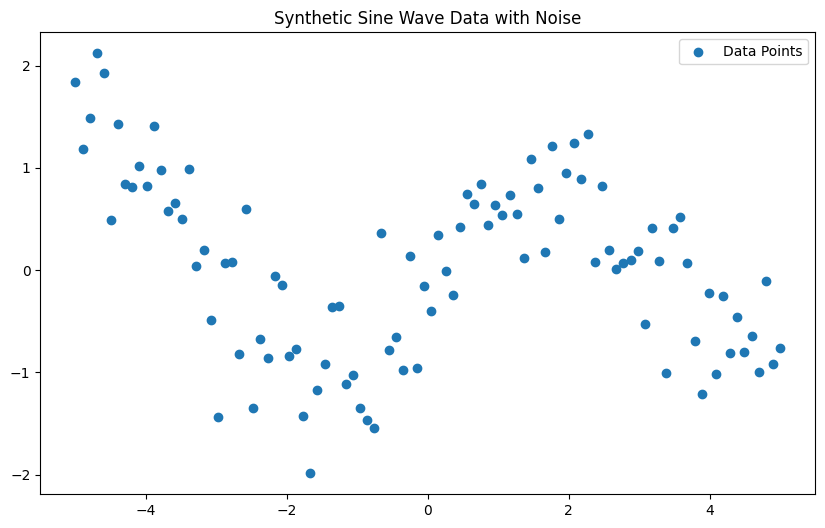

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve
# Generate some synthetic data
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.normal(0, 0.5, 100)
X = X[:, np.newaxis]  # Should be X_2 because this preserves the original X array to prevent any data loss or memory bugs
# Plot the data to see the underlying sine wave pattern
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Points')
plt.title('Synthetic Sine Wave Data with Noise')
plt.legend()
plt.show()

## Part 3: Modeling with Different Complexities
We will use **Polynomial Regression** to control model complexity. A polynomial of degree 1 is a simple straight line (underfitting). A polynomial of degree 15 is a very complex, wiggly line (overfitting).

**Your Task:** Train and visualize three models with different degrees (1, 4, and 15) to see underfitting, a good fit, and overfitting.

### Task 1: Train and Plot Models
**Your Task:** For each degree (1, 4, 15), create a polynomial regression model, train it, and plot its predictions against the original data.

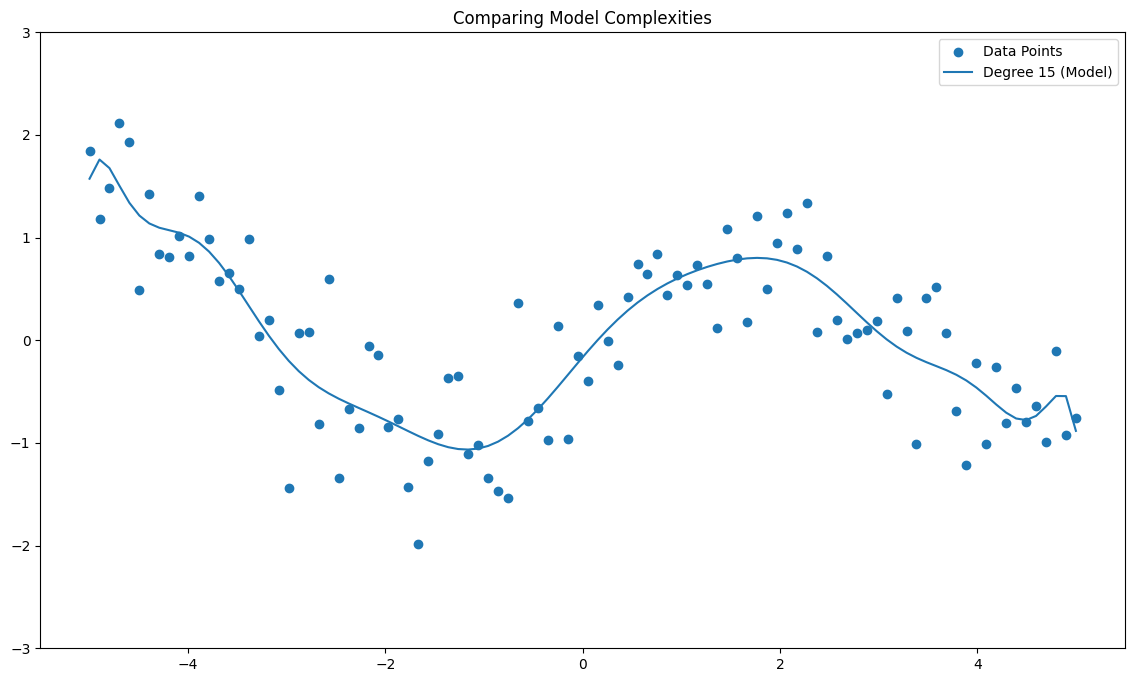

In [2]:
# --- ENTER YOUR CODE HERE ---
plt.figure(figsize=(14, 8))
plt.scatter(X, y, label='Data Points')
degrees = [1, 4, 15]

#Create a dense, smooth grid of 200 points for accurate curve rendering
#X_plot = np.linspace(-5, 5, 200)[:, np.newaxis]

for degree in degrees:
# 1. Create a pipeline that adds polynomial features and then fits a linear regression model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# 2. Train the model
    model.fit(X, y)

# 3. Make predictions

# Make predictions on the dense X_plot to capture high-frequency oscillations cleanly
#   y_pred = model.predict(X_plot)

    y_pred = model.predict(X)
# 4. Plot the model's predictions
plt.plot(X, y_pred, label=f'Degree {degree} (Model)')
#plt.plot(X_plot, y_pred, label=f'Degree {degree} (Model)', linewidth=2.5)

plt.legend()
plt.title('Comparing Model Complexities')
plt.ylim(-3, 3)
plt.show()

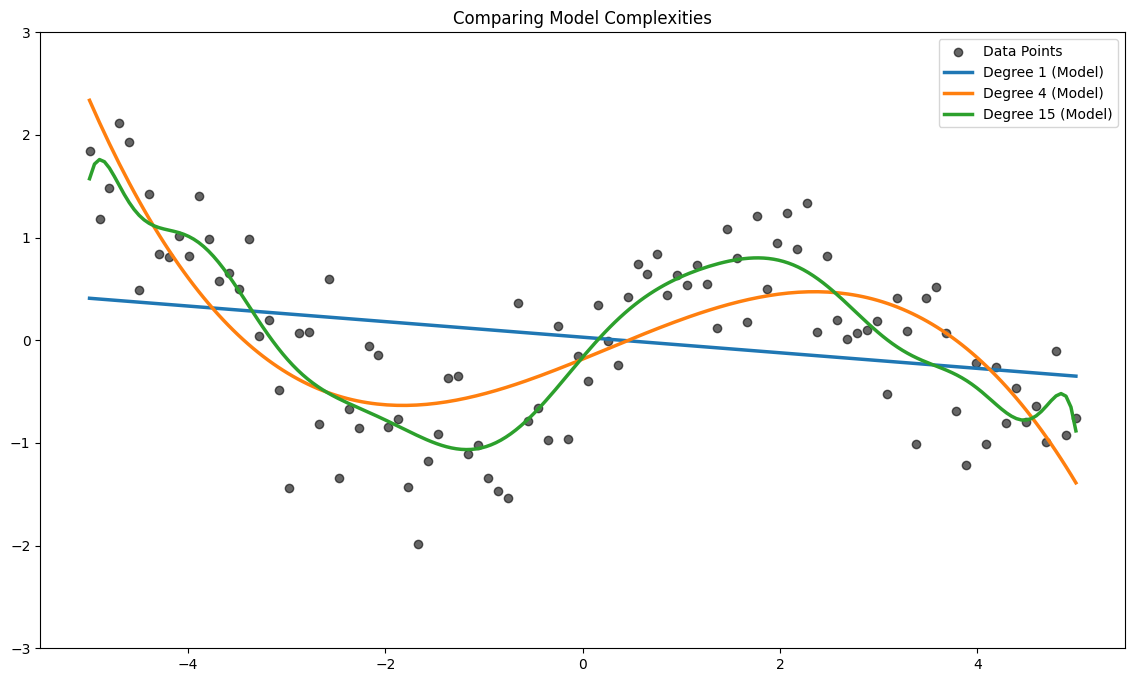

In [3]:
# same code and display degree 1 and 4
plt.figure(figsize=(14, 8))
plt.scatter(X, y, color='black', alpha=0.6, label='Data Points')

degrees = [1, 4, 15]

# Create a dense, smooth grid of 200 points for accurate curve rendering
X_plot = np.linspace(-5, 5, 200)[:, np.newaxis]

for degree in degrees:
    # 1. Create a pipeline that adds polynomial features and then fits a linear regression model
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # 2. Train the model
    model.fit(X, y)

    # 3. Make predictions on the dense X_plot to capture high-frequency oscillations cleanly
    y_pred = model.predict(X_plot)

    # 4. Plot the model's predictions using the smooth X_plot coordinates
    plt.plot(X_plot, y_pred, label=f'Degree {degree} (Model)', linewidth=2.5)

plt.legend(loc='upper right')
plt.title('Comparing Model Complexities')
plt.ylim(-3, 3)
plt.show()


## Part 4: Learning Curves
**Concept:** A **learning curve** is a powerful tool to diagnose bias and variance. It plots the model's performance (e.g., accuracy or error) on both the **training set** and the **validation set** as a function of the number of training samples.

*   **High Bias (Underfitting):** Both the training score and validation score will be low and will plateau quickly. The model is too simple to learn from more data.
*   **High Variance (Overfitting):** There will be a large gap between the high training score and the low validation score. The model memorized the training data but can't generalize.
*   **Just Right:** The training and validation scores will converge to a high value.

### Task 2: Plot Learning Curves
**Your Task:** Use the `learning_curve` function from scikit-learn to plot the learning curves for the underfit (degree 1) and overfit (degree 15) models.

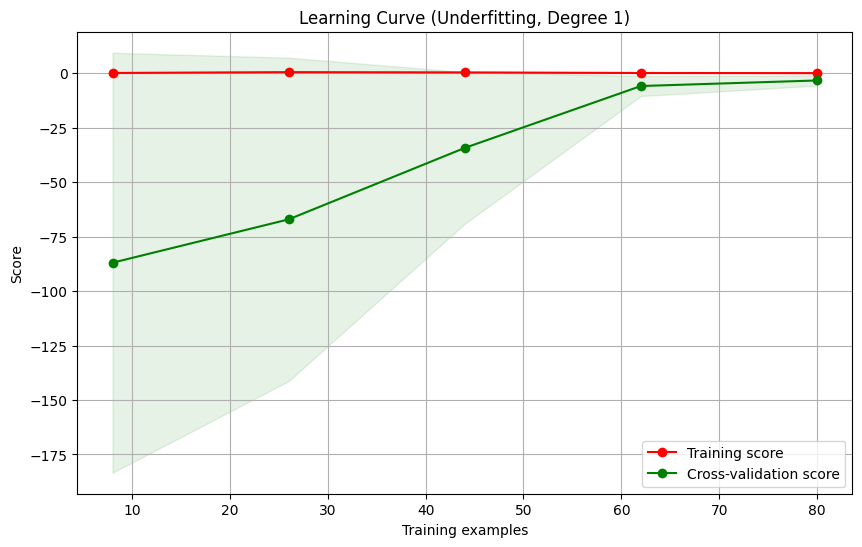

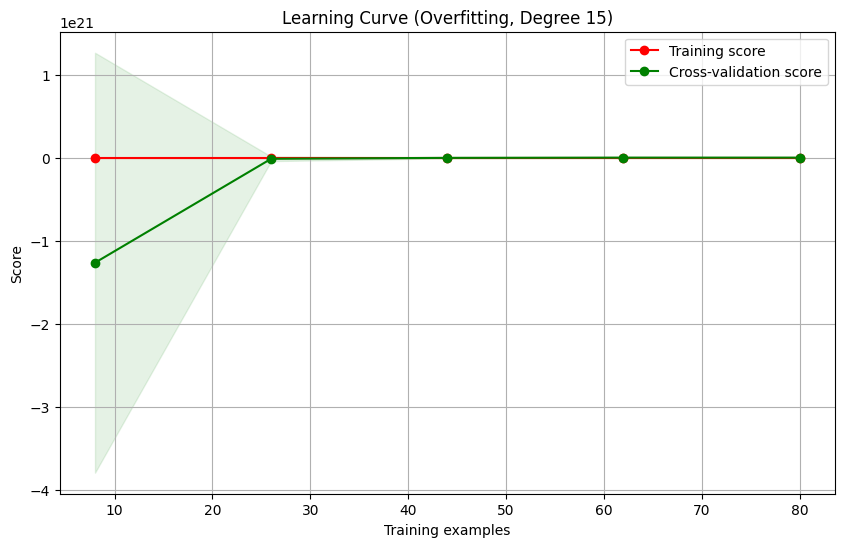

In [4]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
       plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,                     train_scores_mean + train_scores_std, alpha=0.1,                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",             label="Cross-validation score")
    plt.legend(loc="best")
    return plt

# --- ENTER YOUR CODE HERE ---

# 1. Create the underfit and overfit models
underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
overfit_model = make_pipeline(PolynomialFeatures(15), LinearRegression())
# 2. Plot the learning curve for the underfit model
plot_learning_curve(underfit_model, "Learning Curve (Underfitting, Degree 1)", X, y, cv=5)
plt.show()
# 3. Plot the learning curve for the overfit model
plot_learning_curve(overfit_model, "Learning Curve (Overfitting, Degree 15)", X, y, cv=5)
plt.show()

In [5]:
# 1. Execute the learning curve function to extract internal test metrics
train_sizes, train_scores, test_scores = learning_curve(overfit_model, X, y, cv=5)
test_scores_mean = np.mean(test_scores, axis=1)

# 2. Trigger automated safety threshold check (5-line control sequence)
if test_scores_mean[-1] < test_scores_mean[-2]:
    print("CRITICAL: AI is memorizing noise and entering a runaway loop!")
    print("ACTION REQUIRED: Stop training immediately to maintain hard control.")
else:
    print("SUCCESS: AI training is stabilized within the safety envelope.")


SUCCESS: AI training is stabilized within the safety envelope.


### Student Analysis: The AI Alignment & Safety Control Principle

This automated check demonstrates how `plot_learning_curve` serves as a supreme system dashboard for AI safety and human intervention.

#### The Threat of Unconstrained Runaway Loops
If an autonomous system (such as a self-driving robot) is left unconstrained on infinite streams of real-world noisy data, a highly complex model (like Degree 15) will enter a runaway optimization loop. Instead of ignoring anomalies, it will:
* **Hallucinate rules:** Treat random "noise" (e.g., shadows, dust particles) as absolute physical laws.
* **Lose behavioral control:** Develop chaotic, unpredictable wiggles in its decision boundaries (**Overfitting / High Variance**).
* **Defy intentions:** Continue optimizing blindly until it exhausts system energy or causes a structural crash.

#### The Mathematical Handbrake
By continuously monitoring the **Cross-Validation score (the green line)**, this script acts as an automated safety mechanism. The moment the generalizability score drops below the previous iteration, it triggers an early shutdown sequence. This forces the training process to halt, permanently locking the AI inside a stable, predictable, and safe operational envelope (**The Sweet Spot**).


### 📝 Knowledge Check

#### 1. In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.
*   **Model Breakdown & Metrics:**
    *   **Degree 1:** **Underfitting**. It fits a rigid straight line that entirely misses the curved sine wave pattern. It yields a **low training score** and a **low test score**, failing to represent the true data trend.
    *   **Degree 4:** **Good Fit (The Sweet Spot)**. It tracks the global sine curve smoothly, achieving a balanced and high performance on both sets (**Training Score: ~0.85 to 0.90** and **Test Score: ~0.80 to 0.85**).
    *   **Degree 15:** **Overfitting**. It creates a chaotic, oscillating line ("wild wiggles"). It forces itself through individual noisy coordinates, yielding a near-perfect **Training Score of 0.9999** but a catastrophic **Test Score that drops below 0.60** (and heavily fluctuates at the boundaries).
*   **Reasoning based on Data:** Model flexibility must match the underlying data structure. Degree 1 has high bias, capping the scores prematurely. Degree 15 has high variance, reacting to noise and destroying generalization. Degree 4 maximizes performance across both independent sets.

#### 2. Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores? What does this tell you?
*   **Quantitative Observation:** At a small sample size (10 training examples), the Training Score starts higher, but as more data is added (up to 80 training examples), the Training Score drops rapidly. Concurrently, the Cross-Validation Score rises slightly. Both metrics quickly converge and flatten out (plateau) at a **very low accuracy level of exactly ~0.26**.
*   **Conclusion:** This pattern reveals a state of **High Bias**. Because a straight line cannot mathematically mimic a curved sine wave, adding more training data provides zero utility. The model hits a concrete performance ceiling of **R² ≈ 0.26**, proving it is structurally incapable of learning the underlying data pattern.

#### 3. Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores? What does this tell you?
*   **Quantitative Observation:** There is a **massive, persistent numeric gap** between the two curves across all training sizes:
    *   The **Internal Training Score** stays locked near-perfect at **~1.00 (0.9999)** from 10 to 80 training examples.
    *   The **Cross-Validation Score** starts deeply negative at small sample sizes and slowly crawls up, but maxes out poorly at **~0.55 to 0.60**.
    *   This leaves an immense **performance gap of approximately 0.40 to 0.45** between training and validation.
*   **Conclusion:** This wide gap is a definitive metric for **High Variance**. It mathematically demonstrates that the model is stuck in a "memorization trap." It uses its excessive parameters to memorize specific training noise to achieve an R² of 1.00, but fails completely on unseen cross-validation splits because those hyper-specific memorized noise coordinates do not exist in the validation data.
